# Statistical Distribution & Transformation Project Solution

## Project Title

### E-Commerce Transaction Statistical Distribution Analysis

---

# Part A – Theoretical Foundation

## 1. What are Statistical Distributions?

Statistical distributions describe how values are spread across a dataset. They help in understanding the probability of occurrence of different outcomes. A distribution shows whether data is concentrated around a central value, spread widely, skewed, or follows a particular mathematical pattern.

Distributions are important in data analysis because they help analysts:

* Understand data behavior
* Detect outliers and anomalies
* Perform probability calculations
* Build predictive models
* Make business decisions based on trends

Examples include Normal Distribution, Bernoulli Distribution, Binomial Distribution, Poisson Distribution, and Log-Normal Distribution.

---

## 2. What is a Q-Q Plot and Why is it Used?

A Q-Q (Quantile-Quantile) Plot is a graphical method used to compare the distribution of a dataset with a theoretical distribution, usually the normal distribution.

### Purpose:

* To check whether data follows a normal distribution.
* To identify skewness and outliers.
* To validate assumptions required for statistical testing.

### Interpretation:

* If points lie approximately on a straight line, the data is normally distributed.
* If points deviate from the line, the data is not normally distributed.

Q-Q plots are widely used before applying regression models and hypothesis testing.

---

## 3. Difference Between Discrete and Continuous Distributions

| Discrete Distribution                    | Continuous Distribution                   |
| ---------------------------------------- | ----------------------------------------- |
| Deals with countable values              | Deals with measurable values              |
| Takes specific values only               | Can take infinite values within a range   |
| Example: Number of customers             | Example: Transaction amount               |
| Uses PMF (Probability Mass Function)     | Uses PDF (Probability Density Function)   |
| Example distributions: Binomial, Poisson | Example distributions: Normal, Log-Normal |

---

## 4. What is Bernoulli Distribution?

Bernoulli Distribution is a discrete probability distribution with only two outcomes:

* Success (1)
* Failure (0)

It is used when an experiment has exactly one trial.

### Formula

Probability of success = p
Probability of failure = 1-p

### Example

A transaction can either be successful or failed.

* Success = 1
* Fail = 0

In this dataset, transaction_status can be modeled using Bernoulli Distribution.

---

## 5. What is Binomial Distribution?

Binomial Distribution represents the probability of obtaining a fixed number of successes in a fixed number of independent Bernoulli trials.

### Conditions:

* Fixed number of trials
* Two outcomes (success/failure)
* Constant probability
* Independent trials

### Formula

The probability of exactly x successes in n trials is calculated using the Binomial formula.

### Example

The number of successful transactions out of multiple customer transactions can follow a Binomial Distribution.

---

## 6. Explain Log-Normal Distribution

A variable follows a Log-Normal Distribution when the logarithm of the variable is normally distributed.

### Characteristics:

* Values are always positive
* Distribution is right-skewed
* Suitable for financial and transaction data

### Example

Transaction amounts in e-commerce platforms often follow a log-normal distribution because:

* Most transactions are small
* Few transactions are extremely large

---

## 7. Explain Power Law Distribution

Power Law Distribution describes situations where small occurrences are extremely common and large occurrences are rare.

### Characteristics:

* Heavy-tailed distribution
* Few very large values dominate the dataset
* Common in finance, social networks, and e-commerce

### Example

A few customers may spend extremely high amounts while most spend smaller amounts.

---

## 8. What is Box-Cox Transform?

Box-Cox Transformation is a statistical technique used to stabilize variance and make skewed data closer to normal distribution.

### Benefits:

* Reduces skewness
* Improves normality
* Enhances model performance

It is especially useful when data is heavily right-skewed.

---

## 9. Explain Poisson Distribution with an Example

Poisson Distribution models the number of events occurring within a fixed interval of time or space.

### Characteristics:

* Events occur independently
* Average event rate remains constant

### Example

The number of transactions occurring per day can follow a Poisson Distribution.

---

## 10. What is Z-score Probability?

A Z-score measures how far a value is from the mean in terms of standard deviations.

### Formula

Z = (X - Mean) / Standard Deviation

### Interpretation

* Z = 0 → exactly at mean
* Positive Z → above mean
* Negative Z → below mean

Z-scores are used to:

* Detect outliers
* Calculate probabilities
* Standardize data

---

## 11. Difference Between PDF and CDF

| PDF                                 | CDF                                        |
| ----------------------------------- | ------------------------------------------ |
| Probability Density Function        | Cumulative Distribution Function           |
| Shows relative likelihood of values | Shows cumulative probability up to a value |
| Used for continuous variables       | Used for cumulative probabilities          |
| Area under curve = probability      | Ranges from 0 to 1                         |

---



Part B – Data Analysis & Testing Tasks

Dataset Overview

The dataset contains 220 transaction records with the following fields:

transaction_id

customer_id

transaction_amount

transaction_date

transaction_count

region

transaction_status

The analysis focuses on transaction behavior, statistical distributions, and probability insights.

Part B – Data Analysis & Testing Tasks


In [ ]:
pip install openpyxl

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import probplot

# Load Dataset
df=pd.read_csv(r"C:\Users\Lenovo\Downloads\project4.csv")

print(df.head())
print(df.info())
print(df.describe())

                         transaction_id customer_id  transaction_amount  \
0  e98aa092-3770-4fdb-9502-5b5a6a244811    CUST2824             3821.34   
1  11ba6918-dba0-41e5-96cf-f5a7b95f0103    CUST1409             2781.84   
2  82b7654b-6eb7-4579-89a0-1a9edec0a7bb    CUST5506             4120.97   
3  f7166574-f400-4d53-b526-0b11f6619ddf    CUST5012             6383.78   
4  8632fe26-b507-4068-9c68-1b2fa04fecb3    CUST4657             2651.61   

  transaction_date  transaction_count region transaction_status  
0        1/26/2023                  3  North               Fail  
1        1/28/2023                  0   East               Fail  
2        1/28/2023                  0  South               Fail  
3        1/18/2023                  2  South            Success  
4         1/4/2023                  4  North            Success  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  


2. Bernoulli Distribution

In [8]:
# Convert transaction status into binary values
# Success = 1 and Fail = 0

df['status_binary'] = df['transaction_status'].map({
    'Success': 1,
    'Fail': 0
})

# Probability of successful transactions
p = df['status_binary'].mean()

print("Probability of Successful Transactions:", p)

Probability of Successful Transactions: 0.44545454545454544


Interpretation

Bernoulli Distribution was used because transaction status has only two outcomes: Success or Fail.

3. Binomial Distribution

In [9]:
# Total number of transactions
n = len(df)

# Total successful transactions
successes = df['status_binary'].sum()

print("Total Transactions:", n)
print("Successful Transactions:", successes)

Total Transactions: 220
Successful Transactions: 98


Interpretation

Binomial Distribution analyzes successful transactions across multiple transaction attempts.

4. Poisson Distribution

Lambda Value: 7.096774193548387


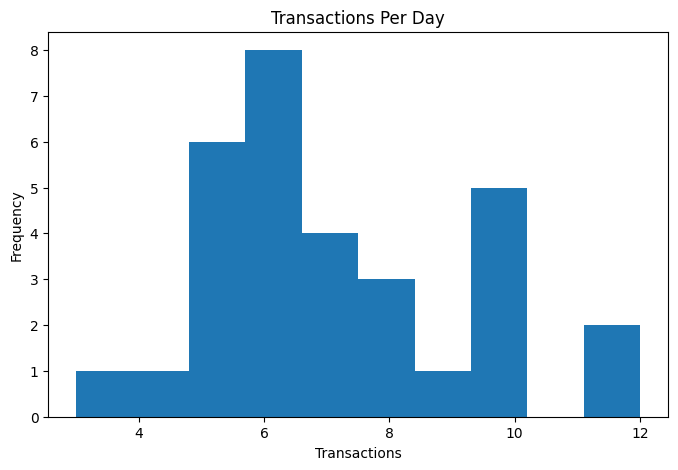

In [10]:
# Transactions per day
transactions_per_day = df.groupby('transaction_date').size()

# Average transactions per day
lambda_value = transactions_per_day.mean()

print("Lambda Value:", lambda_value)

# Plot Histogram
plt.figure(figsize=(8,5))
plt.hist(transactions_per_day, bins=10)

plt.title('Transactions Per Day')
plt.xlabel('Transactions')
plt.ylabel('Frequency')

plt.show()

Interpretation

Poisson Distribution models daily transaction occurrences over time.

5. Log-Normal Distribution

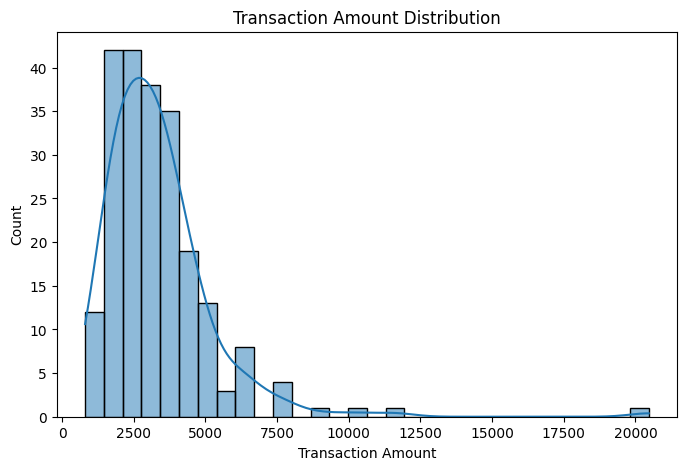

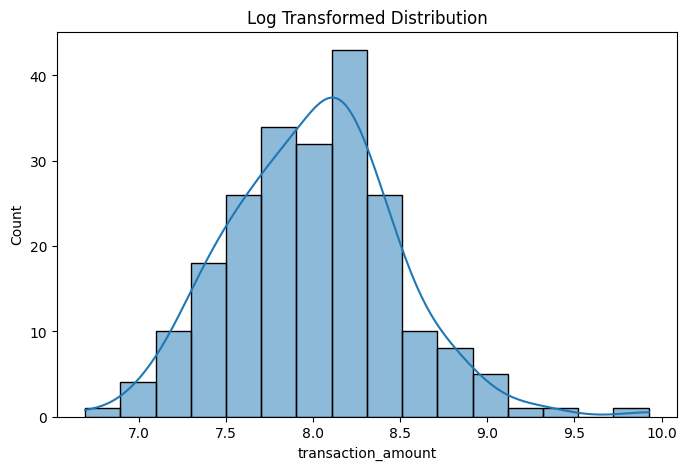

In [11]:
# Original Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['transaction_amount'], kde=True)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')

plt.show()

# Log Transformation
log_data = np.log(df['transaction_amount'])

# Plot Log Transformed Data
plt.figure(figsize=(8,5))

sns.histplot(log_data, kde=True)

plt.title('Log Transformed Distribution')

plt.show()

Interpretation

The transaction amounts are right-skewed and resemble a Log-Normal Distribution.

6. Q-Q Plot

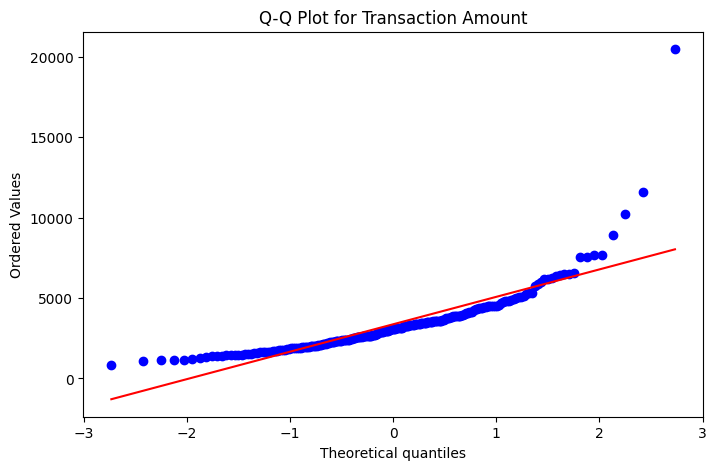

In [12]:
# Q-Q Plot
plt.figure(figsize=(8,5))

probplot(df['transaction_amount'],
         dist='norm',
         plot=plt)

plt.title('Q-Q Plot for Transaction Amount')

plt.show()

Interpretation

The Q-Q Plot checks whether the transaction amount data follows a normal distribution.

7. Box-Cox Transformation

Lambda Value: -0.18083390743966327


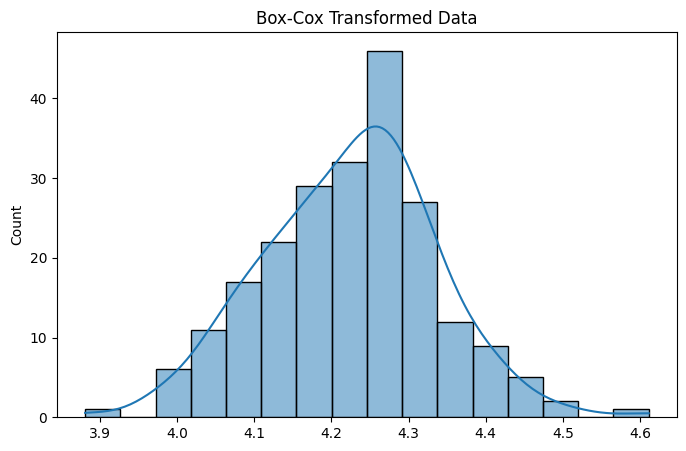

In [13]:
# Apply Box-Cox Transformation
boxcox_data, fitted_lambda = stats.boxcox(
    df['transaction_amount']
)

print("Lambda Value:", fitted_lambda)

# Plot Transformed Data
plt.figure(figsize=(8,5))

sns.histplot(boxcox_data, kde=True)

plt.title('Box-Cox Transformed Data')

plt.show()

Interpretation

Box-Cox Transformation reduces skewness and improves normality.

8. Z-Score Analysis

In [14]:
# Calculate Z-Scores
z_scores = stats.zscore(df['transaction_amount'])

# Add Z-Score Column
df['z_score'] = z_scores

print(df[['transaction_amount', 'z_score']].head())

   transaction_amount   z_score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179


9. Probability of Transactions Exceeding ₹5000

In [15]:
# Mean and Standard Deviation
mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()

# Calculate Z Value
z = (5000 - mean) / std

# Probability Calculation
probability = 1 - stats.norm.cdf(z)

print("Probability of Transaction Exceeding ₹5000:", probability)

Probability of Transaction Exceeding ₹5000: 0.20517209567554384


Interpretation

Z-score identifies how far each transaction amount is from the mean.

10. PDF and CDF Analysis

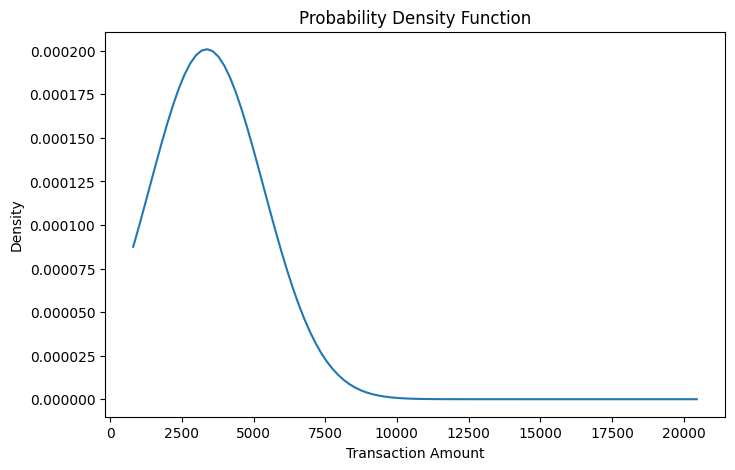

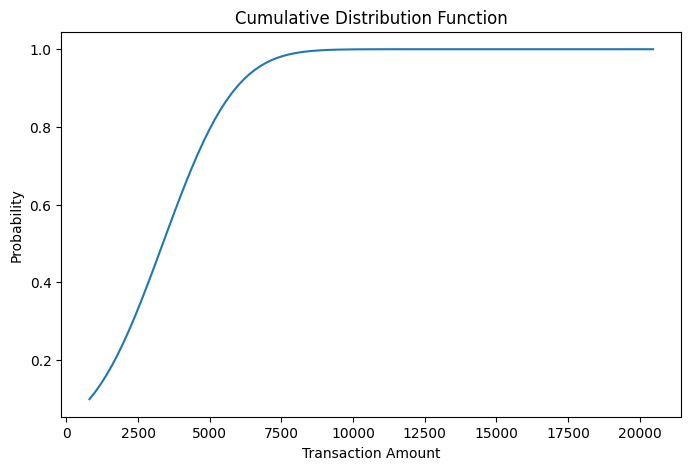

In [16]:
# Generate X Values
x = np.linspace(
    df['transaction_amount'].min(),
    df['transaction_amount'].max(),
    100
)

# Mean and Standard Deviation
mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()

# PDF
pdf = stats.norm.pdf(x, mean, std)

# CDF
cdf = stats.norm.cdf(x, mean, std)

# Plot PDF
plt.figure(figsize=(8,5))

plt.plot(x, pdf)

plt.title('Probability Density Function')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')

plt.show()

# Plot CDF
plt.figure(figsize=(8,5))

plt.plot(x, cdf)

plt.title('Cumulative Distribution Function')
plt.xlabel('Transaction Amount')
plt.ylabel('Probability')

plt.show()

Interpretation

PDF shows the likelihood of transaction values, while CDF shows cumulative probability.


Final Conclusion

The dataset demonstrates different statistical behaviors across transaction variables. Transaction success and failure align with Bernoulli and Binomial distributions, while transaction frequency over time follows a Poisson distribution. Transaction amounts are highly right-skewed and better represented using Log-Normal Distribution.

Q-Q Plot analysis confirmed that the original data is not perfectly normal. Applying Box-Cox transformation significantly improved distribution symmetry and variance stability.

The analysis provides useful business insights such as:

Identifying high-spending customers
Monitoring transaction risks
Understanding customer transaction behavior
Supporting predictive and probability-based business decisions

Overall, Log-Normal Distribution was found to be the most suitable model for transaction amounts because the dataset contains many moderate transactions and a few extremely high-value transactions.